In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from copy import deepcopy
import seaborn as sns
import yaml
from typing import Iterable, Optional, Sequence
from IPython.display import display
from IPython.display import HTML

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import IPythonConsole
from rdkit import DataStructs
import rdkit
from rdkit import RDLogger
# Disable all RDKit logging
RDLogger.DisableLog('rdApp.*')

import warnings

# Suppress the specific FutureWarning about downcasting
warnings.filterwarnings(
    "ignore",
    message="Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated"
)

from matplotlib import pyplot as plt

# Set Path to Models

In [2]:
# Marios partial modality conditioning eval results
eval_dir = Path('/net/galaxy/home/koes/mag1037/work/thesis/OMTRA/outputs/eval')


# Build Directory of Models+Samples

In [ ]:
# Structure: eval_dir/<group>/<model>/<task>_<eval_cond>/samples_<task>/chunk_N_rep_0/eval_metrics.csv
# Groups: no_replay (old models), mixed_25pct (25% full-modality replay)
# Models: whole_frag_plus_atoms, frag_bernoulli, frag_plus_flipped, whole_frags (mixed only)
# Tasks: partial_fixed_protein_ligand_denovo_condensed, partial_rigid_docking_condensed
# Eval conditions: whole_fragments (unified), <training_mode> (in-distribution)

KNOWN_CONDITIONS = [
    "whole_fragments",
    "whole_fragment_plus_atoms",
    "fragment_bernoulli_atom",
    "fragment_plus_flipped_atoms",
    "noised",   # legacy
    "clean",    # legacy
]

rows = []
for group_dir in sorted(eval_dir.iterdir()):
    if not group_dir.is_dir():
        continue
    group_name = group_dir.name  # no_replay or mixed_25pct

    for model_dir in sorted(group_dir.iterdir()):
        if not model_dir.is_dir():
            continue
        model_name = model_dir.name  # e.g. whole_frag_plus_atoms, frag_bernoulli

        for task_cond_dir in sorted(model_dir.iterdir()):
            if not task_cond_dir.is_dir():
                continue
            dirname = task_cond_dir.name
            eval_cond = None
            task_name = None
            for cond in KNOWN_CONDITIONS:
                if dirname.endswith(f"_{cond}"):
                    eval_cond = cond
                    task_name = dirname[: -(len(cond) + 1)]
                    break
            if eval_cond is None:
                continue

            sample_dirs = [sd for sd in task_cond_dir.iterdir() if sd.is_dir() and sd.name.startswith("samples_")]
            for sd in sample_dirs:
                chunk_csvs = sorted(sd.glob("*/eval_metrics.csv"))
                name_id = f"{group_name}/{model_name}"
                row = {
                    "group":       group_name,
                    "model_name":  model_name,
                    "name_id":     name_id,
                    "name":        name_id,
                    "task":        task_name,
                    "dataset":     "plinder",
                    "sample_dir":  str(sd),
                    "eval_cond":   eval_cond,
                    "done":        len(chunk_csvs) > 0,
                    "n_chunks":    len(chunk_csvs),
                }
                rows.append(row)

directory = pd.DataFrame(rows)
print(f"Found {len(directory)} model/task combinations:")
print(directory[["group", "name", "task", "eval_cond", "done", "n_chunks"]].to_string())


# Useful Functions

## general

In [4]:
def summarize_metrics(
    df: pd.DataFrame,
    passfail_metric_cols: Sequence[str] = None,
    continuous_metric_cols: Sequence[str] = None,
    model_col: str = "name",
    include_count: bool = True,
    sort_by: Optional[str] = None,
    ascending: bool = False,
    dropna: bool = True,
) -> pd.DataFrame:
    """
    Group by model and return mean values for the given metric columns.
    
    Args:
        passfail_metric_cols: Pass/fail metrics (coerced to {0,1}, displayed as percentages)
        continuous_metric_cols: Continuous metrics (displayed as raw means)
        model_col: Column to group by
        include_count: Add 'n' column with per-model sample counts
        sort_by: Sort by a column in the result
        ascending: Sort order
        dropna: Drop rows with NA in any metric
    """
    # Handle empty inputs
    passfail_metric_cols = list(passfail_metric_cols) if passfail_metric_cols else []
    continuous_metric_cols = list(continuous_metric_cols) if continuous_metric_cols else []
    all_metric_cols = passfail_metric_cols + continuous_metric_cols
    
    if not all_metric_cols:
        raise ValueError("Must specify at least one metric column")

    # Validate columns
    missing = [c for c in ([model_col] + all_metric_cols) if c not in df.columns]
    if missing:
        raise KeyError(f"Columns not found: {missing}")

    work = df[[model_col, *all_metric_cols]].copy()

    # Optionally drop rows with NA in any metric
    if dropna:
        work = work.dropna(subset=all_metric_cols)

    # Coerce pass/fail metrics to numeric in {0,1}
    for c in passfail_metric_cols:
        if work[c].dtype == bool:
            work[c] = work[c].astype("uint8")
        else:
            # Try soft conversion; if fails, leave as-is (will error on mean if not numeric)
            if not pd.api.types.is_numeric_dtype(work[c].dtype):
                work[c] = (
                    work[c]
                    .map({True: 1, False: 0, "True": 1, "False": 0})
                    .astype("float64", errors="ignore")
                )

    # Aggregate
    agg = work.groupby(model_col, dropna=False)[all_metric_cols].mean()

    # Add count per model if requested
    if include_count:
        counts = work.groupby(model_col, dropna=False).size().rename("n")
        out = pd.concat([counts, agg], axis=1)
    else:
        out = agg

    # Optional sort
    if sort_by is not None:
        if sort_by not in out.columns:
            raise KeyError(f"sort_by '{sort_by}' not in result columns {list(out.columns)}")
        out = out.sort_values(sort_by, ascending=ascending)

    # Stable column order: n (if present) then metrics
    ordered_cols: Iterable[str] = (["n"] if include_count else []) + all_metric_cols
    out = out[ordered_cols]

    return out, passfail_metric_cols


def read_split_eval_metrics(sample_dir: Path) -> pd.DataFrame:

    dfs = []
    for split_file in sample_dir.glob('eval_metrics_*.csv'):
        df_split = pd.read_csv(split_file)
        dfs.append(df_split)
    df = pd.concat(dfs, axis=0, ignore_index=True).reset_index(drop=True)
    return df   

def compute_passes(df):
    df['success_valid_intrecov'] = df['pb_valid'].astype(bool) & (df['interaction_recovery'] == 1.0)
    df['success_hba'] = df['HBAcceptor'] >= df['HBAcceptor_true']
    df['success_hbd'] = df['HBDonor'] >= df['HBDonor_true']
    df['success_hydrophobic'] = df['Hydrophobic'] >= df['Hydrophobic_true']
    df['success_interact'] = df['success_hba'] & df['success_hbd'] & df['success_hydrophobic']
    df['success_valid_abs'] = df['pb_valid'].astype(bool) & df['success_interact']
    return df


def collect_model_dfs(df_dir: pd.DataFrame, set_nan_pb=True) -> pd.DataFrame:
    """Collect evaluation metrics from chunked eval directories into a single DataFrame."""
    dfs = []
    for i in range(len(df_dir)):
        row = df_dir.iloc[i]
        if row['done']:
            sd = Path(row['sample_dir'])
            chunk_csvs = sorted(sd.glob('*/eval_metrics.csv'))
            if not chunk_csvs:
                print(f"No chunk CSVs found for {row['name_id']} / {row['task']}")
                continue
            chunk_dfs = [pd.read_csv(f) for f in chunk_csvs]
            df = pd.concat(chunk_dfs, ignore_index=True)
            df['name'] = row['name_id']
            df['task'] = row['task']

            pb_cols = [c for c in df.columns if c.startswith('pb_') and c != 'pb_index']
            for col in pb_cols:
                df[col] = df[col].replace({'True': True, 'False': False})
                df[col] = pd.to_numeric(df[col], errors='coerce')

            if set_nan_pb:
                pb_fill = df.filter(like='pb_').columns
                n_nan = df['pb_valid'].isna().sum()
                print(f"{row['name_id']}/{row['task']}: {n_nan} NaN PB -> False ({len(chunk_csvs)} chunks, {len(df)} rows)")
                df[pb_fill] = df[pb_fill].fillna(False)
            dfs.append(df)
        else:
            print(f"No data for {row['name_id']} / {row['task']}")

    if not dfs:
        print("No data to concat :(")
        return None

    true = dfs[0][[c for c in dfs[0].columns if '_true' in c and c != 'pb_mol_true_loaded']].copy()
    true.columns = [c[:-5] for c in true.columns]
    true['sys_id'] = dfs[0]['sys_id']
    true['name'] = 'true'
    true = true.drop_duplicates(subset=['sys_id'])
    dfs.append(true)

    df = pd.concat(dfs, axis=0, ignore_index=True).reset_index(drop=True)
    for col in ['HBAcceptor', 'HBDonor', 'Hydrophobic']:
        if col in df.columns and f"{col}_true" in df.columns:
            df[f"{col}_diff"] = (df[col] - df[f"{col}_true"]) / df[f"{col}_true"].mean()
    if 'RDKit_valid' in df.columns:
        df['RDKit_valid'] = df['RDKit_valid'].astype(float)
    df = compute_passes(df)
    return df


def top_n_analysis(df: pd.DataFrame, metrics: list, 
                   sorting_col='minimizedAffinity', ascending=True, n=10,
                   final_rank_col = 'pb_valid', final_rank_ascending=False,
                   group_cols=['name'], final_sort=True) -> pd.DataFrame:
    top_n_dfs = []
    for group_values, df_sys in df.groupby(["sys_id"] + group_cols):
        top_n_df = df_sys.sort_values(by=sorting_col, ascending=ascending).head(n)
        top_n_dfs.append(top_n_df)

    df_top_n = pd.concat(top_n_dfs, axis=0, ignore_index=True).reset_index(drop=True)

    # Average across samples for the same system for a given model
    df_sys_mean = (
        df_top_n.groupby(["sys_id"] + group_cols)[metrics]
        .agg(lambda x: x.median() if x.name == 'strain' else x.mean())
        .reset_index()
    )

    # Average across all systems
    df_model_mean = df_sys_mean.groupby(group_cols)[metrics].mean()

    # Sort by ranking column
    if final_rank_col not in df_model_mean.columns:
        raise KeyError(f"final_rank_col '{final_rank_col}' not found in metrics")

    if final_sort:
        df_model_mean = df_model_mean.sort_values(
            by=final_rank_col, ascending=final_rank_ascending
        )
    return df_model_mean


def top_n_metrics_docking(df: pd.DataFrame,
                          n: int,
                          sorting_col,
                          ascending: bool = True,
                          groupby_cols: list = ['name'],
                          final_sort=True
                          ):
    rows = []
    for gb_vals, df_group in df.groupby(groupby_cols + ['sys_id']):
        val_map = {}
        for col, val in zip(groupby_cols + ['sys_id'], gb_vals):
            val_map[col] = val

        model_name = val_map['name']
        if model_name == 'true':
            continue
        df_top_n = df_group.sort_values(
            by=sorting_col if 'gnina' not in model_name else 'cnn_vs', 
            ascending=ascending if 'gnina' not in model_name else False
            ).head(n)
        success_rmsd = int(df_top_n['pb_rmsd_≤_2å'].any())
        success_rmsd_pb = int(df_top_n['pb_valid'].any())

        row = {}
        for k,v in val_map.items():
            row[k] = v
        row['success_rmsd'] = success_rmsd
        row['success_rmsd_pb'] = success_rmsd_pb
        rows.append(row)
    
    df_top_n = pd.DataFrame(rows)

    df_top_n_summary = df_top_n.groupby(groupby_cols)[['success_rmsd', 'success_rmsd_pb']].mean()
    df_top_n_summary = df_top_n_summary.rename(columns={
        'success_rmsd': 'frac_rmsd2',
        'success_rmsd_pb': 'frac_rmsd2_pb'
    })

    if final_sort:
        df_top_n_summary = df_top_n_summary.sort_values('frac_rmsd2_pb', ascending=True)
    
    return df_top_n_summary


def top_n_metrics_denovo(df: pd.DataFrame,
                          n: int,
                          sorting_col,
                          ascending: bool = True,
                          groupby_cols: list = ['name'],
                          final_sort=True
                          ):
    rows = []
    for gb_vals, df_group in df.groupby(groupby_cols + ['sys_id']):
        val_map = {}
        for col, val in zip(groupby_cols + ['sys_id'], gb_vals):
            val_map[col] = val

        model_name = val_map['name']
        if model_name == 'true':
            continue
        df_top_n = df_group.sort_values(
            by=sorting_col,
            ascending=ascending
            ).head(n)
        # Fraction of systems with at least 1 in top N
        # success_interaction_recovery = int((df_top_n['interaction_recovery'] == 1.0).any())
        # success_pb_valid = int(df_top_n['pb_valid'].any())

        # Average # ligands in top-N across systems
        success_interaction_recovery = (df_top_n['interaction_recovery'] == 1.0).mean()
        success_pb_valid = df_top_n['pb_valid'].mean()

        row = {}
        for k,v in val_map.items():
            row[k] = v
        row['success_interaction_recovery'] = success_interaction_recovery
        row['success_pb'] = success_pb_valid
        rows.append(row)
    
    df_top_n = pd.DataFrame(rows)

    df_top_n_summary = df_top_n.groupby(groupby_cols)[['success_interaction_recovery', 'success_pb']].mean()
    df_top_n_summary = df_top_n_summary.rename(columns={
        'success_interaction_recovery': 'frac_interaction_recovery',
        'success_pb': 'frac_pb_valid'
    })

    if final_sort:
        df_top_n_summary = df_top_n_summary.sort_values('frac_interaction_recovery', ascending=True)
    
    return df_top_n_summary



def load_denovo_design_baselines(denovo_baseline_path, baseline_models, set_nan_pb=False, df_ref=None):
    dfs = []

    for baseline in baseline_models:
        metric_file = denovo_baseline_path / f"{baseline}/samples_fixed_protein_ligand_denovo_condensed_crossdocked/eval_metrics.csv"
        
        if metric_file.exists():
            df_baseline = pd.read_csv(metric_file)
            df_baseline['name'] = baseline
            
            if set_nan_pb:
                pb_cols = df_baseline.filter(like="pb_").columns
                print(f"{baseline}: Setting PoseBusters metrics for {df_baseline['pb_valid'].isna().sum()} ligands to False")
                df_baseline[pb_cols] = df_baseline[pb_cols].fillna(False)
            dfs.append(df_baseline)
        else:
            print(f"WARNING: Could not find metric file for {baseline} at path {metric_file}")
        
    df = pd.concat(dfs, axis=0, ignore_index=True).reset_index(drop=True)

    df['cnn_vs'] = df['CNNscore']*df['CNNaffinity']
    df['cnn_vs_true'] = df['CNNscore_true']*df['CNNaffinity_true']
    for col in ['HBAcceptor', 'HBDonor', 'Hydrophobic']:
        if col in df.columns and f"{col}_true" in df.columns:
            df[f"{col}_diff"] = (df[col] - df[f"{col}_true"]) / df[f"{col}_true"].mean()
    return df


def plot_by_sys(data, metric, order="desc"):
   
    metric_true = f"{metric}_true"

    # Group by system
    grouped = data.groupby('sys_id')

    # Collect replicates + truths
    replicates = [g[metric].dropna().values for _, g in grouped]
    truths = [g[metric_true].iloc[0] for _, g in grouped]
    systems = list(grouped.groups.keys())

    # Sort systems by truth
    reverse = (order == "desc")
    ordered = sorted(zip(systems, replicates, truths), key=lambda x: x[2], reverse=reverse)
    systems, replicates, truths = zip(*ordered)

    # Plot
    fig, ax = plt.subplots(figsize=(12,6))
    bp = ax.boxplot(replicates, positions=range(len(systems)), patch_artist=True)
    ax.scatter(range(len(systems)), truths, color="red", marker="x", s=100, label="Ground truth", zorder=3)

    # Format axes
    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels(systems, rotation=90, ha="right")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}: replicates vs ground truth (sorted {order})")

    plt.tight_layout()
    return fig, ax


# def convert_to_percentages(df, 
#                            columns= [
#     'RDKit_valid',
#     'pb_valid',
#     'interaction_recovery', 
#     # 'strain', 
#     # 'clashes', 
#     # 'minimizedAffinity', 
#     'HBAcceptor_diff',
#     'HBDonor_diff',
#     'Hydrophobic_diff',
# ], 
#     decimal_places=1):
#     """
#     Convert values in specified columns from fractions (0-1) to percentages.
    
#     Args:
#         df: DataFrame to modify
#         columns: List of column names to convert
#         decimal_places: Number of decimal places to round to (default: 1)
    
#     Returns:
#         DataFrame with specified columns converted to percentages
#     """
#     df_copy = df.copy()
    
#     for col in columns:
#         if col in df_copy.columns:
#             df_copy[col] = (df_copy[col] * 100).round(decimal_places)
    
#     return df_copy

def convert_to_percentages(df, 
                           columns= [
                               'RDKit_valid',
                               'pb_valid',
                               'interaction_recovery', 
                               'HBAcceptor_diff',
                               'HBDonor_diff',
                               'Hydrophobic_diff',
                           ], 
                           decimal_places=1):
    """
    Convert values in specified columns from fractions (0-1) to percentages.
    """
    df_copy = df.copy()
    for col in columns:
        if col in df_copy.columns:
            df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')  # <- ensures numeric
            df_copy[col] = (df_copy[col] * 100).round(decimal_places)
    return df_copy

In [5]:
def bootstrap_ci(values, n_boot=2000, ci=0.95, statistic=np.mean, seed=42):
    """Return (mean, lower, upper) bootstrap CI for an array of values."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    boot = np.array([
        statistic(rng.choice(values, size=len(values), replace=True))
        for _ in range(n_boot)
    ])
    alpha = (1 - ci) / 2
    lo = np.percentile(boot, 100 * alpha)
    hi = np.percentile(boot, 100 * (1 - alpha))
    return statistic(values), lo, hi


def summarize_with_ci(
    df,
    metrics,
    pct_cols=None,
    median_cols=None,
    group_col='name',
    n_boot=2000,
    ci=0.95,
):
    """
    Group df by group_col, return a table of 'mean [lo-hi]' strings.
    pct_cols: multiplied by 100 for display (proportion metrics).
    median_cols: use median instead of mean (e.g. strain).
    """
    pct_cols    = set(pct_cols    or [])
    median_cols = set(median_cols or [])

    rows = {}
    for name, grp in df[df[group_col] != 'true'].groupby(group_col):
        row = {}
        for m in metrics:
            if m not in grp.columns:
                row[m] = '-'
                continue
            stat = np.median if m in median_cols else np.mean
            mean, lo, hi = bootstrap_ci(grp[m].values, n_boot=n_boot, ci=ci, statistic=stat)
            scale = 100 if m in pct_cols else 1
            fmt = '.1f' if (m in pct_cols or m in median_cols) else '.3f'
            row[m] = f"{mean*scale:{fmt}} [{lo*scale:{fmt}}-{hi*scale:{fmt}}]"
        rows[name] = row

    return pd.DataFrame(rows).T


## computing diversity df

In [6]:
def compute_pairwise_tanimoto(sdf_file):
    """
    Compute all pairwise Tanimoto similarities for molecules in an SDF file.
    
    Parameters:
    -----------
    sdf_file : str or Path
        Path to the SDF file
    
    Returns:
    --------
    np.ndarray
        Symmetric matrix of pairwise Tanimoto similarities
    """
    # Read molecules from SDF file
    supplier = Chem.SDMolSupplier(str(sdf_file))
    mols = [mol for mol in supplier if mol is not None]
    
    if len(mols) == 0:
        return np.array([])
    
    # create fingerprint generator
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)
    
    # Generate Morgan fingerprints for all molecules
    fps = [mfpgen.GetFingerprint(mol) for mol in mols]
    
    # Compute pairwise Tanimoto similarities using BulkTanimotoSimilarity
    n_mols = len(fps)
    similarity_matrix = np.zeros((n_mols, n_mols))
    
    for i in range(n_mols):
        # Set diagonal to 1.0
        similarity_matrix[i, i] = 1.0
        # Compute similarities to all other fingerprints
        similarities = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])
        # Fill upper triangle
        similarity_matrix[i, i+1:] = similarities
        # Fill lower triangle (symmetric)
        similarity_matrix[i+1:, i] = similarities
    
    return similarity_matrix

def compute_mean_similarity(directory_row: pd.Series):
    row = directory_row
    sample_dir = Path(row.sample_dir)
    results = []

    for chunk_dir in list(sample_dir.glob('chunk_*_rep_*')):
        for sys_dir in chunk_dir.glob('sys_*_gt'):

            sys_info = pd.read_csv(chunk_dir / "sys_info.csv")
            sys_id_map = dict(zip(sys_info["sys_id"], sys_info["system_id"]))

            gen_ligands_file = sys_dir / 'gen_ligands.sdf'
            sim_matrix = compute_pairwise_tanimoto(gen_ligands_file) # has shape (n,n)
            if sim_matrix.size == 0:
                raise ValueError(f"No valid molecules found in {gen_ligands_file}")
            else:
                # Get upper triangular part excluding diagonal
                upper_tri_indices = np.triu_indices_from(sim_matrix, k=1)
                mean_similarity = np.mean(sim_matrix[upper_tri_indices])

            sys_id = sys_id_map.get(sys_dir.name, sys_dir.name)
            results.append({
                'system': sys_id,
                'lig_location': f"{chunk_dir.name}/{sys_dir.name}",
                'mean_tanimoto': mean_similarity
            })

    df = pd.DataFrame(results)
    
    return df

def build_diversity_df(df_dir: pd.DataFrame) -> pd.DataFrame:

    dfs = []
    for _, row in df_dir.iterrows():
        df_model = compute_mean_similarity(row)
        df_model['name'] = row['name_id']
        df_model['task'] = row['task']
        dfs.append(df_model)

    df = pd.concat(dfs, ignore_index=True).reset_index(drop=True)
    return df

# Experiment 1: Does Ligand-Only Pretraining Improve Performance? 

We train single-task models for pocket-conditioned \textit{de novo} design and molecular docking. For each of these conditions, we train models with and without pretraining on the pharmit dataset. This results in a total of four models. The pretraining phase consists of 50\% conformer generation and 50\% de novo design, trained on 2 gpus for ~5 days. 

## denovo design eval

In [ ]:
omtra_mask = (directory['dataset'] == 'plinder') & ((directory['task'] == 'fixed_protein_ligand_denovo_condensed') )
df_plinder_denovo_dir = directory[ omtra_mask ]
df = collect_model_dfs(df_plinder_denovo_dir, set_nan_pb=True)
#df_diversity = build_diversity_df(df_dir)

# –––––––––––– Set Parameters –––––––––––– 
metrics = [
    'RDKit_valid',
    'pb_valid',
    'interaction_recovery', 
    'strain', 
    # 'clashes', 
    # 'minimizedAffinity', 
    'success_interact',
    'success_valid_abs'
]

result_df = df.groupby(['name'])[metrics].mean().round(2).sort_values(by='pb_valid', ascending=False)
result_df = convert_to_percentages(result_df, decimal_places=1)

# replace mean strain with median strain
if 'strain' in metrics:
    strain_series = df.groupby(['name'])[['strain']].median()['strain']
    for v in result_df.index.values:
        if v in strain_series.index:
            result_df.loc[v, 'strain'] = strain_series[v]

name_map = {
    'st_plinder_st_denovo_2_restart': 'not pretrained',
    'st_plinder_st_denovo_seeded_2': 'pretrained',
}

display(HTML("<h2><b>Effect of Pretraining on Denovo Design, Single-Task Models</b></h2>"))
denovo_result_df = result_df.rename(index=name_map).round(2)
denovo_result_df

st_denovo_st_denovo_gnn_st_denovo_seeded: Setting PoseBusters metrics for 81 ligands to False
st_denovo_st_denovo_protformer_st_denovo: Setting PoseBusters metrics for 80 ligands to False
st_denovo_st_denovo_gnn_st_denovo: Setting PoseBusters metrics for 27 ligands to False
mt_mt_protformer: Setting PoseBusters metrics for 97 ligands to False
mt_mt_protformer: Setting PoseBusters metrics for 704 ligands to False
mt_mt_gnn_prot_cond: Setting PoseBusters metrics for 89 ligands to False


,RDKit_valid,pb_valid,interaction_recovery,strain,success_interact,success_valid_abs
name,,,,,,
true,NaN,93.9,NaN,40.98,0.00,0.00
gnn_prot_cond_9m16bjcj,99.0,84.2,47.0,51.49,0.17,0.15
gnn_st_denovo_w46pmnoj,100.0,83.5,50.0,69.48,0.16,0.14
gnn_st_denovo_seeded_wpr1ku5h,99.0,77.3,47.0,51.58,0.14,0.12
protformer_c0rsisjm,99.0,69.4,41.0,107.80,0.12,0.09
protformer_st_denovo_fe7r66ma,99.0,69.2,40.0,105.24,0.09,0.08
protformer_ij3k74my,93.0,54.4,44.0,150.54,0.10,0.07


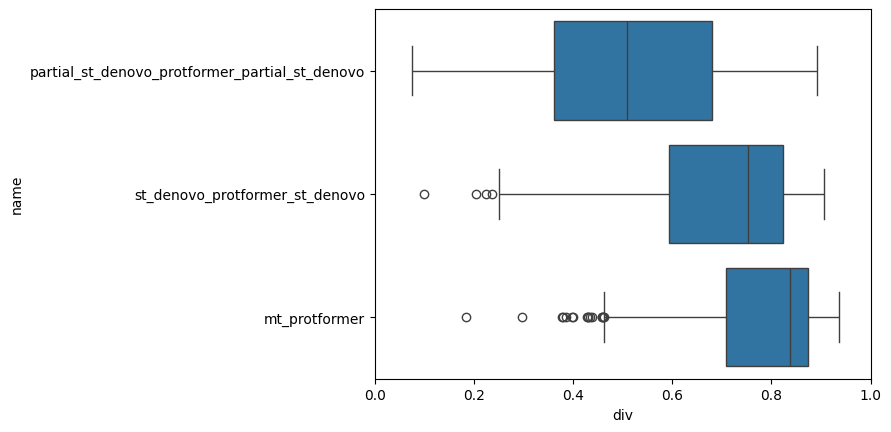

div             
                                                    mean       std   
name                                                                 
mt_protformer                                   0.784661  0.119530  \
partial_st_denovo_protformer_partial_st_denovo  0.515372  0.197319   
st_denovo_protformer_st_denovo                  0.698890  0.153361   

                                               mean_tanimoto            
                                                        mean       std  
name                                                                    
mt_protformer                                       0.215339  0.119530  
partial_st_denovo_protformer_partial_st_denovo      0.484628  0.197319  
st_denovo_protformer_st_denovo                      0.301110  0.153361

In [ ]:
df_diversity = build_diversity_df(df_plinder_denovo_dir)
df_diversity['div'] = 1 - df_diversity['mean_tanimoto']
sns.boxplot(data=df_diversity, y='name', x='div')
plt.xlim(0, 1)
plt.show()

df_diversity.groupby('name')[['div', 'mean_tanimoto']].agg(['mean', 'std'])

## docking eval

In [ ]:
omtra_mask = (directory['dataset'] == 'plinder') & ((directory['task'] == 'partial_rigid_docking_condensed' ) | (directory['task'] == 'rigid_docking_condensed' ))
plinder_dock_df_dir = directory[ omtra_mask ]
df = collect_model_dfs(plinder_dock_df_dir, set_nan_pb=True)
df = df[df['pb_tetrahedral_chirality'] == True]

# –––––––––––– Set Parameters –––––––––––– 
passfail_metric_cols = ['pb_valid', ]
continuous_metric_cols = ['interaction_recovery', 'strain', 'clashes', 'minimizedAffinity', 'HBAcceptor']
# ––––––––––––––––––––––––––––––––––––––––


result_df = top_n_metrics_docking(df, n=5, sorting_col='minimizedAffinity', ascending=True).sort_values('frac_rmsd2_pb', ascending=False)
result_df = convert_to_percentages(result_df, columns=['frac_rmsd2', 'frac_rmsd2_pb'], decimal_places=1)

name_map = {
    'st_plinder_st_docking_2_restart': 'not pretrained',
    'st_plinder_st_docking_seeded_2_restart': 'pretrained',
}
display(HTML("<h2><b>Effect of Pretraining on Docking, Single-Task Models</b></h2>"))
docking_result_df = result_df.rename(index=name_map)
docking_result_df

partial_st_docking_partial_st_docking_protformer_partial_st_docking: Setting PoseBusters metrics for 0 ligands to False
partial_st_docking_partial_st_docking_protformer_partial_st_docking: Setting PoseBusters metrics for 0 ligands to False
mt_mt_protformer: Setting PoseBusters metrics for 0 ligands to False
mt_mt_protformer: Setting PoseBusters metrics for 0 ligands to False
st_docking_st_docking_protformer_st_docking: Setting PoseBusters metrics for 0 ligands to False


,frac_rmsd2,frac_rmsd2_pb
name,,
protformer_partial_st_docking_tstqn9a1,98.0,96.9
protformer_partial_st_docking_x9x53xjs,98.9,96.7
protformer_ij3k74my,97.9,93.7
protformer_c0rsisjm,92.4,88.0
protformer_st_docking_ahjg1lko,93.6,87.2


## combined table for latex export

In [ ]:
# display(denovo_result_df)
# display(docking_result_df)
merged_df = pd.concat([denovo_result_df, docking_result_df], axis=1)

col_name_map = {
    'RDKit_valid': '\\% Valid',
    'pb_valid': '\\% PB-Valid',
    'HBAcceptor_diff': '\\% $\\Delta$ HBA',
    'HBDonor_diff': '\\% $\\Delta$ HBD',
    'Hydrophobic_diff': '\\% $\\Delta$ Hydroph',
    'frac_rmsd2': '\\% RMSD $\\le$ 2\\AA\\',
    'frac_rmsd2_pb': '\\% PB-Valid',
}
merged_df = merged_df.rename(columns=col_name_map)

# merged_df.columns = merged_df.columns.str.replace('_', ' ')

# build top header
top = (["denovo design"] * (merged_df.shape[1] - 2)) + ["docking", "docking"]
cols = pd.MultiIndex.from_arrays([top, merged_df.columns])

df_labeled = pd.DataFrame(merged_df.to_numpy(), index=merged_df.index, columns=cols)

# one decimal, clean NaNs, no "name & ..." header row
latex_str = df_labeled.round(1).to_latex(
    multicolumn=True,
    multicolumn_format='c',
    float_format=lambda x: f"{x:.1f}",
    na_rep="",
    index_names=False,
    caption='Effect of Pretraining On \\textit{De Novo} Design and Docking'
)

print(latex_str)

\begin{table}
\caption{Effect of Pretraining On \textit{De Novo} Design and Docking}
\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{6}{c}{denovo design} & \multicolumn{2}{c}{docking} \\
 & \% Valid & \% PB-Valid & strain & $\Delta$ HBA & $\Delta$ HBD & $\Delta$ Hydroph & \% RMSD ≤ 2Å & \% PB-Valid \\
\midrule
true &  & 94.0 & 39.2 &  &  &  &  &  \\
not pretrained & 98.0 & 71.0 & 96.2 & -17.0 & -28.0 & 6.0 & 92.0 & 75.0 \\
pretrained & 97.0 & 67.0 & 125.6 & -15.0 & -22.0 & 3.0 & 91.0 & 73.0 \\
\bottomrule
\end{tabular}
\end{table}



# Experiment 2:Does Multi-Task Training Improve Performance?

We train multi-task models; that is, models trained both for \textit{de novo} design and molecular docking simultaneously. These models are also pharmit-pretrained. We compare them to pharmit-pretrained single-task OMTRA models. We perform denovo design and docking evaluations between the multi-task and corresponding single-task models. 

## denovo design eval

In [ ]:
directory

,group,model_name,name_id,max_steps,task,dataset,sample_dir,name,done
0,partial_st_denovo,partial_st_denovo,partial_st_denovo_5g2in99r,400000,partial_fixed_protein_ligand_denovo_condensed,plinder,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_partial_st_denovo,True
1,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,,std=1.0,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,False
2,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,,std=1.25,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,False
3,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,,std=0.25,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,False
4,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,,std=0,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,False
5,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,partial_fixed_protein_ligand_denovo,condensed,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,False
6,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,,std=0.75,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,False
7,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,partial_fixed_protein_ligand_denovo_condensed,plinder,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,True
8,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,,std=1.5,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,False
9,partial_st_denovo,protformer_partial_st_denovo,protformer_partial_st_denovo_8rn0ioh1,3000000,,std=0.5,/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trai...,partial_st_denovo_protformer_partial_st_denovo,False


In [ ]:
mask = (directory['task'].isin(['partial_fixed_protein_ligand_denovo_condensed']))  & (directory['dataset'] == 'plinder') 
df_dir = directory[ mask ]

df = collect_model_dfs(df_dir, set_nan_pb=True)

metrics = [
    'RDKit_valid',
    'pb_valid',
    # 'interaction_recovery', 
    'strain', 
    # 'clashes', 
    # 'minimizedAffinity', 
    # 'HBAcceptor_diff',
    # 'HBDonor_diff',
    # 'Hydrophobic_diff',
    'success_interact',
    'success_valid_abs'
]

result_df = df.groupby(['name'])[metrics].mean().round(2).sort_values(by='pb_valid', ascending=False)
result_df = convert_to_percentages(result_df, decimal_places=1)

# replace mean strain with median strain
if 'strain' in metrics:
    strain_series = df.groupby(['name'])[['strain']].median()['strain'].round(2)
    for v in result_df.index.values:
        if v in strain_series.index:
            result_df.loc[v, 'strain'] = strain_series[v]

name_map = {
    'st_plinder_st_denovo_2_restart': 'ST',
    'st_plinder_st_denovo_seeded_2': 'ST-pretrained',
    'mt_plinder_prot_cond': 'MT',
    'mt_plinder_prot_protpharm_cond': 'MT +pharms',
    'st_plinder_st_denovo_seeded_new': 'new ST-pretrained'
}

# result_df = result_df.drop(index='st_plinder_st_denovo_seeded_2', errors='ignore')

display(HTML("<h2><b>Effect of Multitask Training on Denovo Design, Plinder</b></h2>"))
# result_df.rename(index=name_map)
denovo_result_df = result_df.rename(index=name_map).sort_values(by='pb_valid', ascending=False)
denovo_result_df

partial_st_denovo_partial_st_denovo_partial_st_denovo: Setting PoseBusters metrics for 948 ligands to False
partial_st_denovo_partial_st_denovo_protformer_partial_st_denovo: Setting PoseBusters metrics for 83 ligands to False
partial_st_denovo_partial_st_denovo_protformer_partial_st_denovo: Setting PoseBusters metrics for 327 ligands to False
mt_mt_gnn_partial_prot_cond: Setting PoseBusters metrics for 62 ligands to False


,RDKit_valid,pb_valid,strain,success_interact,success_valid_abs
name,,,,,
true,NaN,94.0,41.39,0.00,0.00
gnn_partial_prot_cond_dyzotztt,99.0,85.1,62.12,0.25,0.22
protformer_partial_st_denovo_8rn0ioh1,99.0,66.0,171.86,0.14,0.11
protformer_partial_st_denovo_elyamt0d,97.0,58.3,214.79,0.14,0.11
partial_st_denovo_5g2in99r,91.0,57.9,135.30,0.19,0.14


In [ ]:
df = pd.read_csv('/net/galaxy/home/koes/ltoft/OMTRA_2/OMTRA/trained_models/mt/gnn_partial_prot_cond_2026-03-23_19-21-493411/samples_partial_fixed_protein_ligand_denovo_condensed_plinder/chunk_10_rep_0/eval_metrics.csv')
df[df['pb_valid'] == True]

,sys_id,protein_id,gen_ligand_id,RDKit_valid,pb_mol_pred_loaded,pb_mol_cond_loaded,pb_sanitization,pb_inchi_convertible,pb_all_atoms_connected,pb_no_radicals,...,clashes_true,strain_true,HBAcceptor_true,HBDonor_true,Hydrophobic_true,PiStacking_true,system_id,ligand_id,ccd,n_gt_lig_atoms
0,sys_0_gt,protein_0,gen_ligands_0,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23
1,sys_0_gt,protein_0,gen_ligands_1,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23
2,sys_0_gt,protein_0,gen_ligands_2,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23
3,sys_0_gt,protein_0,gen_ligands_3,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23
4,sys_0_gt,protein_0,gen_ligands_4,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,sys_0_gt,protein_0,gen_ligands_95,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23
96,sys_0_gt,protein_0,gen_ligands_96,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23
97,sys_0_gt,protein_0,gen_ligands_97,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23
98,sys_0_gt,protein_0,gen_ligands_98,True,True,True,True,True,True,True,...,11.0,48.100642,0.217391,0.130435,0.304348,0.0,6y88__6__1.F__1.U,1.U,137,23


In [ ]:
display(df.loc[:, df.columns.str.startswith('pb_') & ~df.columns.str.endswith('_true')])

## docking eval

In [ ]:
mask = (directory['task'] == 'partial_rigid_docking_condensed')  & (directory['dataset'] == 'plinder')
df_dir = directory[ mask ]

df = collect_model_dfs(df_dir, set_nan_pb=True)
df = df[df['pb_tetrahedral_chirality'] == True]

# –––––––––––– Set Parameters –––––––––––– 
passfail_metric_cols = ['pb_valid', ]
continuous_metric_cols = ['interaction_recovery', 'strain', 'clashes', 'minimizedAffinity', 'HBAcceptor']
# ––––––––––––––––––––––––––––––––––––––––

# –––––––––––– Set Parameters –––––––––––– 
n = 5
sorting_col='minimizedAffinity'
ascending = True
# ––––––––––––––––––––––––––––––––––––––––

top_n_any = top_n_metrics_docking(df, n=n, sorting_col=sorting_col, ascending=ascending).sort_values('frac_rmsd2_pb', ascending=False)

metrics = [
    # 'pb_valid', 
    # 'pb_rmsd_≤_2å',
    'interaction_recovery', 
    # 'HBAcceptor',
    # 'HBDonor',
    # 'Hydrophobic',
    # 'PiStacking',
    'strain',
    # 'cnn_vs',
    # 'minimizedAffinity', 
    # 'clashes'
    ]


# top n where n is chosen by gnina score
top_n_mean = top_n_analysis(df, 
               metrics=metrics, 
               sorting_col='minimizedAffinity',
               ascending=True, 
               final_rank_col='interaction_recovery',
            #    final_rank_col='pb_rmsd_≤_2å',
            #    final_rank_col='pb_valid',
               n=n
               ).round(3)

combined = top_n_mean.join(top_n_any, how='inner')

name_map = {
    'mt_plinder_prot_cond': 'MT',
    'mt_plinder_prot_protpharm_cond': 'MT +pharms',
    'st_plinder_st_docking_2_restart': 'ST',
    'st_plinder_st_docking_seeded_2_restart': 'ST-pretrained',
    'st_plinder_st_docking_seeded_new': 'new ST-pretrained'
}

combined = combined.drop(columns=['strain', 'interaction_recovery'])
combined = convert_to_percentages(combined, columns=['frac_rmsd2', 'frac_rmsd2_pb'], decimal_places=1)


docking_result_df = combined.rename(index=name_map).sort_values('frac_rmsd2_pb', ascending=False)
docking_result_df

partial_st_docking_partial_st_docking_protformer_partial_st_docking: Setting PoseBusters metrics for 0 ligands to False
partial_st_docking_partial_st_docking_protformer_partial_st_docking: Setting PoseBusters metrics for 0 ligands to False
mt_mt_gnn_partial_prot_cond: Setting PoseBusters metrics for 0 ligands to False


/net/galaxy/home/koes/ltoft/.conda/envs/omtra_2/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/net/galaxy/home/koes/ltoft/.conda/envs/omtra_2/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/net/galaxy/home/koes/ltoft/.conda/envs/omtra_2/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,frac_rmsd2,frac_rmsd2_pb
name,,
protformer_partial_st_docking_tstqn9a1,98.0,96.9
protformer_partial_st_docking_x9x53xjs,98.9,96.7
gnn_partial_prot_cond_dyzotztt,98.8,94.1


## combine tables for latex export

In [ ]:
merged_df = pd.concat([denovo_result_df, docking_result_df], axis=1)

# drop rows with index MT +pharms and ST-pretrained
merged_df = merged_df.drop(index=['MT +pharms', 'ST'])

col_name_map = {
    'RDKit_valid': '\\% Valid',
    'pb_valid': '\\% PB-Valid',
    'HBAcceptor_diff': '\\% $\\Delta$ HBA',
    'HBDonor_diff': '\\% $\\Delta$ HBD',
    'Hydrophobic_diff': '\\% $\\Delta$ Hydroph',
    'frac_rmsd2': '\\% RMSD $\\le$ 2\\AA\\',
    'frac_rmsd2_pb': '\\% PB-Valid',
}
merged_df = merged_df.rename(columns=col_name_map)

# merged_df.columns = merged_df.columns.str.replace('_', ' ')

# build top header
top = (["denovo design"] * (merged_df.shape[1] - 2)) + ["docking", "docking"]
cols = pd.MultiIndex.from_arrays([top, merged_df.columns])

df_labeled = pd.DataFrame(merged_df.to_numpy(), index=merged_df.index, columns=cols)

# one decimal, clean NaNs, no "name & ..." header row
latex_str = df_labeled.round(1).to_latex(
    multicolumn=True,
    multicolumn_format='c',
    float_format=lambda x: f"{x:.1f}",
    na_rep="",
    index_names=False,
    caption='Effect of Multitask Training On \\textit{De Novo} Design and Docking'
)

print(latex_str)

\begin{table}
\caption{Effect of Multitask Training On \textit{De Novo} Design and Docking}
\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{6}{c}{denovo design} & \multicolumn{2}{c}{docking} \\
 & \% Valid & \% PB-Valid & strain & \% $Delta$ HBA & \% $\Delta$ HBD & \% $\Delta$ Hydroph & \% RMSD $\le$ 2\AA\ & \% PB-Valid \\
\midrule
true &  & 94.0 & 39.2 &  &  &  &  &  \\
MT & 98.0 & 70.0 & 69.6 & -24.0 & -36.0 & 7.0 & 95.0 & 75.0 \\
ST-pretrained & 97.0 & 67.0 & 125.6 & -15.0 & -22.0 & 3.0 & 91.0 & 73.0 \\
\bottomrule
\end{tabular}
\end{table}



# Experiment 2B: Partial Modality Conditioning

## denovo design

In [ ]:
mask = (directory['task'].isin(['partial_fixed_protein_ligand_denovo_condensed_std1.5']))  & (directory['dataset'] == 'plinder') 
df_dir = directory[ mask ]

df = collect_model_dfs(df_dir, set_nan_pb=True)

metrics = [
    'RDKit_valid',
    'pb_valid',
    # 'interaction_recovery', 
    'strain', 
    # 'clashes', 
    # 'minimizedAffinity', 
    # 'HBAcceptor_diff',
    # 'HBDonor_diff',
    # 'Hydrophobic_diff',
    'success_interact',
    'success_valid_abs'
]

result_df = df.groupby(['name'])[metrics].mean().round(2).sort_values(by='pb_valid', ascending=False)
result_df = convert_to_percentages(result_df, decimal_places=1)

# replace mean strain with median strain
if 'strain' in metrics:
    strain_series = df.groupby(['name'])[['strain']].median()['strain'].round(2)
    for v in result_df.index.values:
        if v in strain_series.index:
            result_df.loc[v, 'strain'] = strain_series[v]

name_map = {
    'st_plinder_st_denovo_2_restart': 'ST',
    'st_plinder_st_denovo_seeded_2': 'ST-pretrained',
    'mt_plinder_prot_cond': 'MT',
    'mt_plinder_prot_protpharm_cond': 'MT +pharms',
    'st_plinder_st_denovo_seeded_new': 'new ST-pretrained'
}

# result_df = result_df.drop(index='st_plinder_st_denovo_seeded_2', errors='ignore')

display(HTML("<h2><b>Effect of Multitask Training on Denovo Design, Plinder</b></h2>"))
# result_df.rename(index=name_map)
denovo_result_df = result_df.rename(index=name_map).sort_values(by='pb_valid', ascending=False)
denovo_result_df

mt_mt_gnn_partial_prot_cond: Setting PoseBusters metrics for 43 ligands to False


,RDKit_valid,pb_valid,strain,success_interact,success_valid_abs
name,,,,,
gnn_partial_prot_cond_dyzotztt,100.0,87.2,55.85,0.25,0.24
true,NaN,66.7,46.22,0.00,0.00


# Experiment 3: How does pharmacophore conditioning impact performance?
We pre-train an OMTRA model on unconditional denovo+conformer, followed by a pretraining phase of pharmacophore-conditioned denovo+conformer, before finally training an OMTRA model for protein-conditioned tasks. We run the same denovo design + docking evals 

## denovo design

In [ ]:
task_mask =  directory['task'].isin(['fixed_protein_pharmacophore_ligand_denovo_condensed', 'fixed_protein_ligand_denovo_condensed'])
name_mask = directory['name'] == 'mt_plinder_prot_protpharm_cond'
mask = name_mask & task_mask  & (directory['dataset'] == 'plinder')
df_dir = directory[ mask ]

df = collect_model_dfs(df_dir, set_nan_pb=True)

metrics = [
    # 'RDKit_valid',
    'pb_valid',
    'interaction_recovery',
    # 'strain', 
    # 'clashes', 
    # 'minimizedAffinity', 
    # 'HBAcceptor_diff',
    # 'HBDonor_diff',
    # 'Hydrophobic_diff',
    'frac_true_pharms_matched'
]

denovo_result_df = df.groupby(['name', 'task'])[metrics].mean()


# replace mean strain with median strain
if 'strain' in metrics:
    strain_series = df.groupby(['name', 'task'])[['strain']].median()['strain'].round(2)
    for v in denovo_result_df.index.values:
        if v in strain_series.index:
            denovo_result_df.loc[v, 'strain'] = strain_series[v]


denovo_result_df = convert_to_percentages(denovo_result_df, decimal_places=1)
denovo_result_df = convert_to_percentages(denovo_result_df, columns=['frac_true_pharms_matched'], decimal_places=1)
denovo_result_df = denovo_result_df.droplevel("name").rename_axis("name").round(1)

name_map = {
    'fixed_protein_ligand_denovo_condensed': 'Prot Conditioning',
    'fixed_protein_pharmacophore_ligand_denovo_condensed': 'Prot + Pharm Conditioning',
}


denovo_result_df = denovo_result_df.rename(index=name_map)
denovo_result_df

mt_plinder_mt_plinder_prot_protpharm_cond: Setting PoseBusters metrics for 130 ligands to False
mt_plinder_mt_plinder_prot_protpharm_cond: Setting PoseBusters metrics for 190 ligands to False


,pb_valid,interaction_recovery,frac_true_pharms_matched
name,,,
Prot Conditioning,67.5,51.0,NaN
Prot + Pharm Conditioning,66.2,67.4,96.9


## denovo design top-n

In [ ]:
top_n_analysis(
    df, 
    metrics=metrics, 
    sorting_col='minimizedAffinity',
    ascending=True, 
    n=5, 
    group_cols=['name', 'task'],
    final_sort=False).round(2)

RDKit_valid  \
name                                   task                                                             
mt_plinder_prot_cond                   fixed_protein_ligand_denovo_condensed                    0.964   
mt_plinder_prot_protpharm_cond         fixed_protein_ligand_denovo_condensed                    0.982   
                                       fixed_protein_pharmacophore_ligand_denovo_conde...        0.98   
mt_plinder_protpharm_cond              fixed_protein_pharmacophore_ligand_denovo_conde...       0.978   
plinder_and_crossdocked_mt_prot_cd     fixed_protein_ligand_denovo_condensed                    0.972   
st_plinder_st_denovo_2_restart         fixed_protein_ligand_denovo_condensed                    0.984   
st_plinder_st_denovo_seeded_2          fixed_protein_ligand_denovo_condensed                    0.928   
st_suboptimal_plinder_st_denovo_seeded fixed_protein_ligand_denovo_condensed                    0.974   

                                                                                           pb_valid  \
name                                   task                                                           
mt_plinder_prot_cond                   fixed_protein_ligand_denovo_condensed                   0.89   
mt_plinder_prot_protpharm_cond         fixed_protein_ligand_denovo_condensed                   0.84   
                                       fixed_protein_pharmacophore_ligand_denovo_conde...      0.79   
mt_plinder_protpharm_cond              fixed_protein_pharmacophore_ligand_denovo_conde...      0.78   
plinder_and_crossdocked_mt_prot_cd     fixed_protein_ligand_denovo_condensed                   0.88   
st_plinder_st_denovo_2_restart         fixed_protein_ligand_denovo_condensed                   0.87   
st_plinder_st_denovo_seeded_2          fixed_protein_ligand_denovo_condensed                   0.80   
st_suboptimal_plinder_st_denovo_seeded fixed_protein_ligand_denovo_condensed                   0.82   

                                                                                           interaction_recovery  \
name                                   task                                                                       
mt_plinder_prot_cond                   fixed_protein_ligand_denovo_condensed                               0.55   
mt_plinder_prot_protpharm_cond         fixed_protein_ligand_denovo_condensed                               0.56   
                                       fixed_protein_pharmacophore_ligand_denovo_conde...                  0.72   
mt_plinder_protpharm_cond              fixed_protein_pharmacophore_ligand_denovo_conde...                  0.65   
plinder_and_crossdocked_mt_prot_cd     fixed_protein_ligand_denovo_condensed                               0.40   
st_plinder_st_denovo_2_restart         fixed_protein_ligand_denovo_condensed                               0.61   
st_plinder_st_denovo_seeded_2          fixed_protein_ligand_denovo_condensed                               0.64   
st_suboptimal_plinder_st_denovo_seeded fixed_protein_ligand_denovo_condensed                               0.55   

                                                                                           strain  \
name                                   task                                                         
mt_plinder_prot_cond                   fixed_protein_ligand_denovo_condensed               109.23   
mt_plinder_prot_protpharm_cond         fixed_protein_ligand_denovo_condensed               171.45   
                                       fixed_protein_pharmacophore_ligand_denovo_conde...  248.80   
mt_plinder_protpharm_cond              fixed_protein_pharmacophore_ligand_denovo_conde...  213.73   
plinder_and_crossdocked_mt_prot_cd     fixed_protein_ligand_denovo_condensed               139.51   
st_plinder_st_denovo_2_restart         fixed_protein_ligand_denovo_condensed               182.18   
st_plinder_st_denovo_seeded_2          fixed_prot

## docking

In [ ]:
task_mask =  directory['task'].isin(['rigid_docking_pharmacophore_condensed', 'rigid_docking_condensed'])
name_mask = directory['name'] == 'mt_plinder_prot_protpharm_cond'
mask = name_mask & task_mask  & (directory['dataset'] == 'plinder')
df_dir = directory[ mask ]
df = collect_model_dfs(df_dir, set_nan_pb=True)
df = df[df['pb_tetrahedral_chirality'] == True]


docking_result_df = top_n_metrics_docking(
    df, 
    n=5, 
    sorting_col='minimizedAffinity', 
    ascending=True,
    groupby_cols=['name', 'task'],
    # groupby_cols=['task'],
    final_sort=False
    )

top_n_mean = top_n_analysis(df, 
               metrics=['frac_true_pharms_matched'], 
               sorting_col='minimizedAffinity',
               ascending=True, 
               group_cols=['name', 'task'],
               final_rank_col='frac_true_pharms_matched',
            #    final_rank_col='pb_rmsd_≤_2å',
            #    final_rank_col='pb_valid',
               n=5
               ).round(3)

docking_result_df = pd.concat([docking_result_df, top_n_mean], axis=1)

# drop the 'name' level
docking_result_df = docking_result_df.droplevel("name").rename_axis("name")
docking_result_df = convert_to_percentages(docking_result_df, columns=['frac_rmsd2', 'frac_rmsd2_pb', 'frac_true_pharms_matched'], decimal_places=1)

name_map = {
    'rigid_docking_condensed': 'Prot Conditioning',
    'rigid_docking_pharmacophore_condensed': 'Prot + Pharm Conditioning',
}

column_map = {
    'frac_true_pharms_matched': 'frac_true_pharms_matched_docking',
}

docking_result_df = docking_result_df.rename(index=name_map, columns=column_map)
docking_result_df

mt_plinder_mt_plinder_prot_protpharm_cond: Setting PoseBusters metrics for 0 ligands to False
mt_plinder_mt_plinder_prot_protpharm_cond: Setting PoseBusters metrics for 0 ligands to False


,frac_rmsd2,frac_rmsd2_pb,frac_true_pharms_matched_docking
name,,,
Prot Conditioning,95.8,91.6,NaN
Prot + Pharm Conditioning,99.0,92.7,99.3


In [ ]:
task_mask =  directory['task'].isin(['rigid_docking_pharmacophore_condensed', 'rigid_docking_condensed'])
name_mask = directory['name'] == 'mt_plinder_prot_protpharm_cond'
mask = name_mask & task_mask  & (directory['dataset'] == 'plinder')
df_dir = directory[ mask ]
df = collect_model_dfs(df_dir, set_nan_pb=True)
df = df[df['pb_tetrahedral_chirality'] == True]


docking_result_df = top_n_metrics_docking(
    df, 
    n=5, 
    sorting_col='minimizedAffinity', 
    ascending=True,
    groupby_cols=['name', 'task'],
    # groupby_cols=['task'],
    final_sort=False
    )
docking_result_df

mt_plinder_mt_plinder_prot_protpharm_cond: Setting PoseBusters metrics for 0 ligands to False
mt_plinder_mt_plinder_prot_protpharm_cond: Setting PoseBusters metrics for 0 ligands to False


frac_rmsd2   
name                           task                                                
mt_plinder_prot_protpharm_cond rigid_docking_condensed                  0.957895  \
                               rigid_docking_pharmacophore_condensed    0.989583   

                                                                      frac_rmsd2_pb  
name                           task                                                  
mt_plinder_prot_protpharm_cond rigid_docking_condensed                     0.915789  
                               rigid_docking_pharmacophore_condensed       0.927083

In [ ]:
top_n_mean = top_n_analysis(df, 
               metrics=['frac_true_pharms_matched'], 
               sorting_col='minimizedAffinity',
               ascending=True, 
               group_cols=['name', 'task'],
               final_rank_col='frac_true_pharms_matched',
            #    final_rank_col='pb_rmsd_≤_2å',
            #    final_rank_col='pb_valid',
               n=5
               ).round(3)

top_n_mean

pd.concat([docking_result_df, top_n_mean], axis=1)

frac_rmsd2   
name                           task                                                
mt_plinder_prot_protpharm_cond rigid_docking_condensed                  0.957895  \
                               rigid_docking_pharmacophore_condensed    0.989583   

                                                                      frac_rmsd2_pb   
name                           task                                                   
mt_plinder_prot_protpharm_cond rigid_docking_condensed                     0.915789  \
                               rigid_docking_pharmacophore_condensed       0.927083   

                                                                      frac_true_pharms_matched  
name                           task                                                             
mt_plinder_prot_protpharm_cond rigid_docking_condensed                                     NaN  
                               rigid_docking_pharmacophore_condensed                     0.993

## merge denovo+docking results

In [ ]:
merged_df.T

name,Prot Conditioning,Prot + Pharm Conditioning
\% PB-Valid,67.5,66.2
interaction_recovery,51.0,67.4
\% Pharm Matches (denovo),NaN,96.9
\% RMSD $\le$ 2\AA\,93.0,99.0
\% PB-Valid,73.0,81.0
\% Pharm Matches (docking),NaN,99.5


In [ ]:
merged_df

,\% PB-Valid,interaction recovery,\% Pharm Matches (denovo),\% RMSD $\le$ 2\AA\,\% PB-Valid,\% Pharm Matches (docking)
name,,,,,,
Prot Conditioning,67.5,51.0,NaN,93.0,73.0,NaN
Prot + Pharm Conditioning,66.2,67.4,96.9,99.0,81.0,99.5


In [ ]:
merged_df = pd.concat([denovo_result_df, docking_result_df], axis=1)

# drop rows with index MT +pharms and ST-pretrained
# merged_df = merged_df.drop(index=['MT +pharms', 'ST'])

col_name_map = {
    'RDKit_valid': '\\% Valid',
    'pb_valid': '\\% PB-Valid',
    'HBAcceptor_diff': '$\\Delta$ HBA',
    'HBDonor_diff': '$\\Delta$ HBD',
    'Hydrophobic_diff': '$\\Delta$ Hydroph',
    'frac_rmsd2': '\\% RMSD $\\le$ 2\\AA\\',
    'frac_rmsd2_pb': '\\% PB-Valid',
    'frac_true_pharms_matched': '\\% Pharm Matches (denovo)',
    'frac_true_pharms_matched_docking': '\\% Pharm Matches (docking)',
}
merged_df = merged_df.rename(columns=col_name_map)

merged_df.columns = merged_df.columns.str.replace('_', ' ')

# build top header
top = (["denovo design"] * (merged_df.shape[1] - 2)) + ["docking", "docking"]
cols = pd.MultiIndex.from_arrays([top, merged_df.columns])

df_labeled = pd.DataFrame(merged_df.to_numpy(), index=merged_df.index, columns=cols)

# one decimal, clean NaNs, no "name & ..." header row
latex_str = df_labeled.T.round(1).to_latex(
    multirow=True,
    multicolumn=True,
    multicolumn_format='c',
    float_format=lambda x: f"{x:.1f}",
    na_rep="-",
    index_names=False,
    caption='Effect of Multitask Training On \\textit{De Novo} Design and Docking',
)

print(latex_str)

\begin{table}
\caption{Effect of Multitask Training On \textit{De Novo} Design and Docking}
\begin{tabular}{llrr}
\toprule
 & name & Prot Conditioning & Prot + Pharm Conditioning \\
\midrule
\multirow[t]{4}{*}{denovo design} & \% PB-Valid & 67.5 & 66.2 \\
 & interaction recovery & 51.0 & 67.4 \\
 & \% Pharm Matches (denovo) & - & 96.9 \\
 & \% RMSD $\le$ 2\AA\ & 93.0 & 99.0 \\
\cline{1-4}
\multirow[t]{2}{*}{docking} & \% PB-Valid & 73.0 & 81.0 \\
 & \% Pharm Matches (docking) & - & 99.5 \\
\cline{1-4}
\bottomrule
\end{tabular}
\end{table}



# Experiment 4: How Does OMTRA Compare to Existing SOTA Methods

OMTRA is, essentially, an extension of FlowMol3 (in architecture and generative model formulation) to the multi-task setting. FlowMol3 achieved state of the art performance on unconditional molecule design; so now we ask the question, how does this translate to protein-conditioned design tasks? We compare OMTRA to de novo design methods on the crossdocked splits provided by whomeever. We compare OMTRA to conventional and deep-learning based molecular docking methods by evaluating its performance on the PoseBusters Benchmark set. It is important to note in the case of the PB benchmark set, we have not taken care to remove overlap between the training distribution and the posebuster's benchmark set. So our results here are preliminary and probably optimistic. 

## denovo design on the crossdocked dataset

In [ ]:
omtra_mask = (directory['dataset'] == 'crossdocked') & (directory['task'] == 'fixed_protein_ligand_denovo_condensed' )
cd_df_dir = directory[ omtra_mask ]
omtra_cd_df = collect_model_dfs(cd_df_dir)

denovo_baseline_path = Path('/net/galaxy/home/koes/ltoft/OMTRA/omtra_pipelines/docking_eval/outputs_crossdocked')
baseline_models = ['diffsbdd', 'drugflow', 'pocket2mol', 'targetdiff']
baseline_df = load_denovo_design_baselines(denovo_baseline_path, baseline_models)


### put ground-truth values for each system into the baseline_df from omtra_cd_df
cols = ['HBAcceptor_true', 'HBDonor_true', 'Hydrophobic_true']
for col in cols:
    baseline_df[col] = np.nan

sys_ids = omtra_cd_df['sys_id'].unique().tolist()
for sys_id in sys_ids:
    mask = omtra_cd_df['sys_id'] == sys_id
    hba_true = omtra_cd_df[mask]['HBAcceptor_true'].values[0]
    hbd_true = omtra_cd_df[mask]['HBDonor_true'].values[0]
    hydrophobic_true = omtra_cd_df[mask]['Hydrophobic_true'].values[0]
    
    baseline_df.loc[baseline_df['sys_id'] == sys_id, 'HBAcceptor_true'] = hba_true
    baseline_df.loc[baseline_df['sys_id'] == sys_id, 'HBDonor_true'] = hbd_true
    baseline_df.loc[baseline_df['sys_id'] == sys_id, 'Hydrophobic_true'] = hydrophobic_true

baseline_df['HBAcceptor_diff'] = (baseline_df['HBAcceptor'] - baseline_df['HBAcceptor_true']) / baseline_df['HBAcceptor_true'].mean()
baseline_df['HBDonor_diff'] = (baseline_df['HBDonor'] - baseline_df['HBDonor_true']) / baseline_df['HBDonor_true'].mean()
baseline_df['Hydrophobic_diff'] = (baseline_df['Hydrophobic'] - baseline_df['Hydrophobic_true']) / baseline_df['Hydrophobic_true'].mean()
#####


cd_df = pd.concat([omtra_cd_df, baseline_df], axis=0, ignore_index=True).reset_index(drop=True)

metrics = [
    # 'RDKit_valid',
    'pb_valid',
    # 'interaction_recovery',
    'strain', 
    # 'clashes', 
    'minimizedAffinity', 
    # 'HBAcceptor',
    # 'HBDonor',
    # 'Hydrophobic',
    'HBAcceptor_diff',
    'HBDonor_diff',
    'Hydrophobic_diff',
]

top_n = True

if not top_n:
    result_df = cd_df.groupby(['name'])[metrics].mean().round(2)
if top_n:
    # result_df = top_n_analysis(cd_df, metrics=metrics, n=10)
    result_df = top_n_metrics_denovo(cd_df, n=5, sorting_col='minimizedAffinity', ascending = True, groupby_cols= ['name'])

# replace mean strain with median strain
if 'strain' in metrics and not top_n:
    strain_series = cd_df.groupby(['name'])[['strain']].median()['strain'].round(1)
    for v in result_df.index.values:
        if v in strain_series.index:
            result_df.loc[v, 'strain'] = strain_series[v]

name_map = {
    'crossdocked_mt_prot_cd': 'omtra multitask',
    'crossdocked_st_denovo_cd': 'omtra single-task',
    # 'plinder_and_crossdocked_mt_prot_cd': 'omtra multitask, plinder+crossdocked',
    'plinder_and_crossdocked_mt_prot_cd': 'OMTRA',

}

col_name_map = {
    'RDKit_valid': '\\% Valid',
    'pb_valid': '\\% PB-Valid',
    'HBAcceptor_diff': '$\\Delta$ HBA',
    'HBDonor_diff': '$\\Delta$ HBD',
    'Hydrophobic_diff': '$\\Delta$ Hydroph',
    'frac_rmsd2': '\\% RMSD $\\le$ 2\\AA\\',
    'frac_rmsd2_pb': '\\% PB-Valid',
    'minimizedAffinity': 'Vina Score',
}

# name_map = {}
display(HTML("<h2><b>OMTRA + baseline methods, Denovo Design on Crossdocked</b></h2>"))
#result_df['pb_valid'] = result_df['pb_valid'].astype(float)
result_df = convert_to_percentages(result_df, columns=['frac_interaction_recovery', 'frac_pb_valid'], decimal_places=1)
# result_df = convert_to_percentages(result_df, columns=['HBAcceptor_diff', 'HBDonor_diff', 'Hydrophobic_diff'], decimal_places=1)
result_df = result_df.sort_values(by='frac_interaction_recovery', ascending=False).round(2)
result_df = result_df.rename(index=name_map, columns=col_name_map)

names_to_drop = ['omtra multitask', 'omtra single-task']
# names_to_drop = ['omtra multitask, plinder+crossdocked', 'omtra single-task']
result_df = result_df.drop(index=names_to_drop)

result_df

plinder_and_crossdocked_plinder_and_crossdocked_mt_prot_cd: Setting PoseBusters metrics for 80 ligands to False
crossdocked_crossdocked_st_denovo_cd: Setting PoseBusters metrics for 1673 ligands to False
crossdocked_crossdocked_mt_prot_cd: Setting PoseBusters metrics for 193 ligands to False


,frac_interaction_recovery,frac_pb_valid
name,,
targetdiff,12.1,34.5
drugflow,11.6,70.5
OMTRA,10.7,94.9
diffsbdd,10.5,36.3
pocket2mol,9.3,90.9


In [ ]:
result_df

,frac_interaction_recovery,frac_pb_valid
name,,
crossdocked_st_denovo_cd,0.255814,0.930233
crossdocked_mt_prot_cd,0.267442,1.000000
pocket2mol,0.465116,1.000000
diffsbdd,0.523256,0.872093
plinder_and_crossdocked_mt_prot_cd,0.534884,1.000000
drugflow,0.581395,0.941860
targetdiff,0.604651,0.860465


In [ ]:
print(result_df.to_latex(
    float_format=lambda x: f"{x:.1f}",
    na_rep="-",
    caption='Pocket-Conditioned De Novo Design on Crossdocked, OMTRA + Baselines'
))

\begin{table}
\caption{Pocket-Conditioned De Novo Design on Crossdocked, OMTRA + Baselines}
\begin{tabular}{lrrrrrr}
\toprule
 & \% PB-Valid & strain & Vina Score & $\Delta$ HBA & $\Delta$ HBD & $\Delta$ Hydroph \\
name &  &  &  &  &  &  \\
\midrule
true & 97.7 & 20.7 & -7.1 & - & - & - \\
OMTRA & 91.2 & 25.3 & -6.7 & -22.0 & -49.0 & 20.0 \\
pocket2mol & 86.6 & 24.0 & -4.5 & -11.0 & -31.0 & 29.0 \\
drugflow & 73.4 & 72.5 & -5.9 & 8.0 & -8.0 & 5.0 \\
targetdiff & 47.7 & 445.8 & -6.8 & -0.0 & -13.0 & 6.0 \\
diffsbdd & 38.2 & 545.8 & -2.8 & -20.0 & -37.0 & 6.0 \\
\bottomrule
\end{tabular}
\end{table}



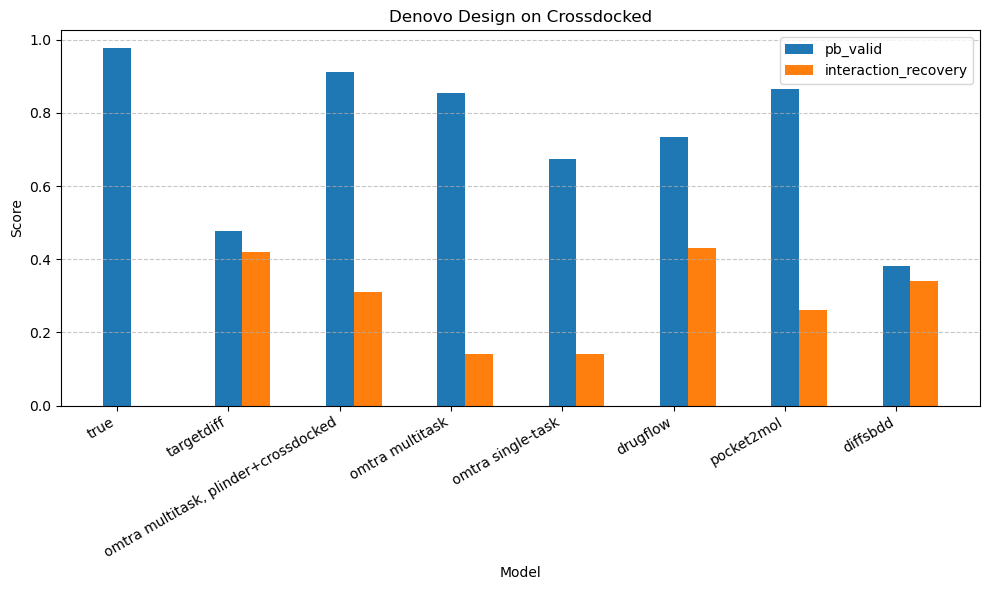

In [ ]:
# Drop the "true" row since it's not a model
# plot_df = cd_df.groupby(['name'])[metrics].mean().drop(cd_df[cd_df.index == "true"].index)
plot_df = result_df.copy()

# Set up figure
fig, ax = plt.subplots(figsize=(10,6))

# Bar positions
x = np.arange(len(plot_df.index))  
width = 0.25  

# Plot each metric side by side
# ax.bar(x - width, plot_df["RDKit_valid"], width, label="RDKit_valid")
ax.bar(x, plot_df["pb_valid"], width, label="pb_valid")
ax.bar(x + width, plot_df["interaction_recovery"], width, label="interaction_recovery")

# Formatting
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_title("Denovo Design on Crossdocked")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha="right")
ax.legend()

# Add gridlines for clarity
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## docking on posebusters

In [14]:
top_n_df = None

omtra_mask = (directory['dataset'] == 'posebusters') & (directory['task'] == 'rigid_docking_condensed' )
pb_df_dir = directory[ omtra_mask ]

gnina_row = {
    'group': 'gnina',
    'model_name': 'gnina',
    'name_id': 'gnina',
    'max_steps': 0,
    'dataset': 'posebusters',
    'task': 'rigid_docking_condensed',
    'sample_dir': '/net/galaxy/home/koes/icd3/moldiff/OMTRA/local/gnina_spoof/',
    'name': 'gnina',
    'done': True
}
pb_df_dir = pd.concat([pb_df_dir, pd.DataFrame([gnina_row])], ignore_index=True).reset_index(drop=True)

pb_df = collect_model_dfs(pb_df_dir)

mask = pb_df['name'].isin([
  'gnina', 
  'mt_plinder_prot_cond', 
  # 'mt_plinder_prot_protpharm_cond', 
  'st_plinder_st_docking_seeded_2_restart'
  ])
pb_df = pb_df[mask]
pb_df = pb_df[pb_df['pb_tetrahedral_chirality'] == True]
dfs = []
for n in [1, 5]:
  top_n_df = top_n_metrics_docking(pb_df,
                        n=n,
                        # sorting_col='cnn_vs',
                        sorting_col='minimizedAffinity',
                        # ascending=False,
                        ascending=True,
                        ).sort_values('frac_rmsd2_pb', ascending=False)
  top_n_df.columns = [f"{col}_top{n}" for col in top_n_df.columns]
  dfs.append(top_n_df)

  

top_n_df = pd.concat(dfs, axis=1)
top_n_df = convert_to_percentages(top_n_df, columns=['frac_rmsd2_top1', 'frac_rmsd2_pb_top1', 'frac_rmsd2_top5', 'frac_rmsd2_pb_top5'], decimal_places=1)

No chunk CSVs found for gnina / rigid_docking_condensed
No data to concat :(


TypeError: 'NoneType' object is not subscriptable

In [15]:
if top_n_df is not None:
    name_map = {
        'gnina': 'Gnina',
        'mt_plinder_prot_cond': 'OMTRA, multitask',
        'st_plinder_st_docking_seeded_2_restart': 'OMTRA, single-task',
    }
    column_map = {
        'frac_rmsd2_top1': '\\% RMSD $\\le$ 2\\AA\\',
        'frac_rmsd2_pb_top1': '\\% PB-Valid',
        'frac_rmsd2_top5': '\\% RMSD $\\le$ 2\\AA\\',
        'frac_rmsd2_pb_top5': '\\% PB-Valid',
    }
    
    # sort by minimizedAffinity
    df_latex = top_n_df.rename(index=name_map).sort_values(by='frac_rmsd2_pb_top5', ascending=False).rename(columns=column_map)
    display(df_latex)

In [16]:
if top_n_df is not None:
    name_map = {
        'gnina': 'Gnina',
        'mt_plinder_prot_cond': 'OMTRA, multitask',
        'st_plinder_st_docking_seeded_2_restart': 'OMTRA, single-task',
    }
    column_map = {
        'frac_rmsd2_top1': '\\% RMSD $\\le$ 2\\AA\\',
        'frac_rmsd2_pb_top1': '\\% PB-Valid',
        'frac_rmsd2_top5': '\\% RMSD $\\le$ 2\\AA\\',
        'frac_rmsd2_pb_top5': '\\% PB-Valid',
    }
    
    # sort by minimizedAffinity
    df_latex = top_n_df.rename(index=name_map).sort_values(by='frac_rmsd2_pb_top5', ascending=False).rename(columns=column_map)
    display(df_latex)
    
    # merged_df.columns = merged_df.columns.str.replace('_', ' ')
    
    # build top header
    top = ['$N=1$']*2 + ['$N=5$']*2
    cols = pd.MultiIndex.from_arrays([top, df_latex.columns])
    
    df_latex = pd.DataFrame(df_latex.to_numpy(), index=df_latex.index, columns=cols)
    
    latex_str = df_latex.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        float_format=lambda x: f"{x:.1f}",
        na_rep="",
        index_names=False,
        caption='Docking Performance on Posebusters Benchmark'
    )
    print(latex_str)

In [ ]:
# Partial Modality Conditioning Results
# Compare old (no replay) vs mixed (25% full-modality replay) models
# F = whole_fragments eval (unified), O = own trained modality eval
# 95% bootstrap CIs computed over all generated ligands

model_display_names = {
    'no_replay/whole_frag_plus_atoms':     'Whole frag + atoms (75%)',
    'no_replay/frag_bernoulli':            'Frags – some atoms (25%)',
    'no_replay/frag_plus_flipped':         'Arb. mix (50%)',
    'mixed_25pct/whole_frags':             '25%full - Whole frags (50%)',
    'mixed_25pct/whole_frag_plus_atoms':   '25%full - Whole frag+atoms (75%)',
    'mixed_25pct/frag_bernoulli':          '25%full - Frags–atoms (25%)',
    'mixed_25pct/frag_plus_flipped':       '25%full - Arb.mix (50%)',
}

# own eval condition per model (the masking mode it was trained on)
own_eval_cond = {
    'no_replay/whole_frag_plus_atoms':     'whole_fragment_plus_atoms',
    'no_replay/frag_bernoulli':            'fragment_bernoulli_atom',
    'no_replay/frag_plus_flipped':         'fragment_plus_flipped_atoms',
    'mixed_25pct/whole_frags':             'whole_fragments',
    'mixed_25pct/whole_frag_plus_atoms':   'whole_fragment_plus_atoms',
    'mixed_25pct/frag_bernoulli':          'fragment_bernoulli_atom',
    'mixed_25pct/frag_plus_flipped':       'fragment_plus_flipped_atoms',
}

PCT_COLS    = ['RDKit_valid', 'pb_valid', 'pb_rmsd_≤_2å', 'success_interact',
               'success_valid_abs', 'interaction_recovery']
MEDIAN_COLS = ['strain']

metrics_denovo  = ['pb_valid', 'strain', 'interaction_recovery', 'success_interact', 'success_valid_abs']
metrics_docking = ['pb_valid', 'strain', 'interaction_recovery', 'success_interact', 'pb_rmsd_≤_2å']


def get_result(directory, task, name_ids, eval_cond, metrics):
    mask = (
        (directory['task'] == task) &
        (directory['eval_cond'] == eval_cond) &
        (directory['name'].isin(name_ids))
    )
    df_dir = directory[mask]
    if df_dir.empty:
        return None
    df = collect_model_dfs(df_dir, set_nan_pb=True)
    if df is None:
        return None
    valid_metrics = [m for m in metrics if m in df.columns]
    result = summarize_with_ci(
        df,
        metrics=valid_metrics,
        pct_cols=PCT_COLS,
        median_cols=MEDIAN_COLS,
        group_col='name',
        n_boot=2000,
        ci=0.95,
    )
    result.index = result.index.map(lambda x: model_display_names.get(x, x))
    return result


for task, metrics in [
    ('partial_fixed_protein_ligand_denovo_condensed', metrics_denovo),
    ('partial_rigid_docking_condensed', metrics_docking),
]:
    display(HTML(f'<h3>{task}</h3>'))

    all_name_ids = list(model_display_names.keys())

    # Frag: all models with whole_fragments eval
    result_frag = get_result(directory, task, all_name_ids, 'whole_fragments', metrics)
    if result_frag is None:
        print(f'No frag data for {task}')
        continue

    # Own: per model, load its own eval condition
    own_rows = {}
    for name_id, display_name in model_display_names.items():
        o_cond = own_eval_cond[name_id]
        r_own = get_result(directory, task, [name_id], o_cond, metrics)
        if r_own is not None and display_name in r_own.index:
            own_rows[display_name] = r_own.loc[display_name]
    result_own = pd.DataFrame(own_rows).T if own_rows else None

    # Reindex to display order and interleave F/O columns
    display_order = list(model_display_names.values())
    result_frag = result_frag.reindex(display_order)
    if result_own is not None:
        result_own = result_own.reindex(display_order)

    metric_cols = result_frag.columns.tolist()
    interleaved_cols, rename_f, rename_o = [], {}, {}
    for col in metric_cols:
        rename_f[col] = f'{col} F'
        rename_o[col] = f'{col} O'
        interleaved_cols += [f'{col} F', f'{col} O']

    df_f = result_frag.rename(columns=rename_f)
    df_o = result_own.rename(columns=rename_o) if result_own is not None else pd.DataFrame(index=display_order)
    combined = pd.concat([df_f, df_o], axis=1)[interleaved_cols]
    display(combined)
